In [1]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

# 1. Lettura Dati

In [2]:
def nome (stringa):

    stringa_nuova = stringa.replace(f'./Data/','').replace('.csv','')
    return stringa_nuova

In [3]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)
    data[nome(input_file)] = {}


    for key in letti.keys():
        colonna = letti[key]
        try:
            # prova a convertirla in float
            data[nome(input_file)][key] = colonna.astype(float).to_numpy()
        except ValueError:
            # se non ci riesce, tieni le stringhe
            data[nome(input_file)][key] = colonna.astype(str).to_list()

# 2. Analisi Dati

In [4]:
err = 0

Le incertezze sui pixel è $\frac{1}{\sqrt{12}}$ e sulle intensità è il 5% della misura (eventualmente posso sommare in quadratura l'errore di riposizionamento del laser trovato per il Punto 6).

Il fit è fatto con la minimizzazione del $\chi^2$ e le incertezze sono quindi quelle derivate dal fit.

Il vertice è stato trovato con la formula:
$$
V = ( -\frac{b}{2a}, -\frac{b^2 - 4ac}{4a} )
$$

Per le incertezze sulle coordinate del vertice è stata usata la classica propagazione delle incertezze, senza però usare la covarianza tra i parametri che infatti non è stata stimata.

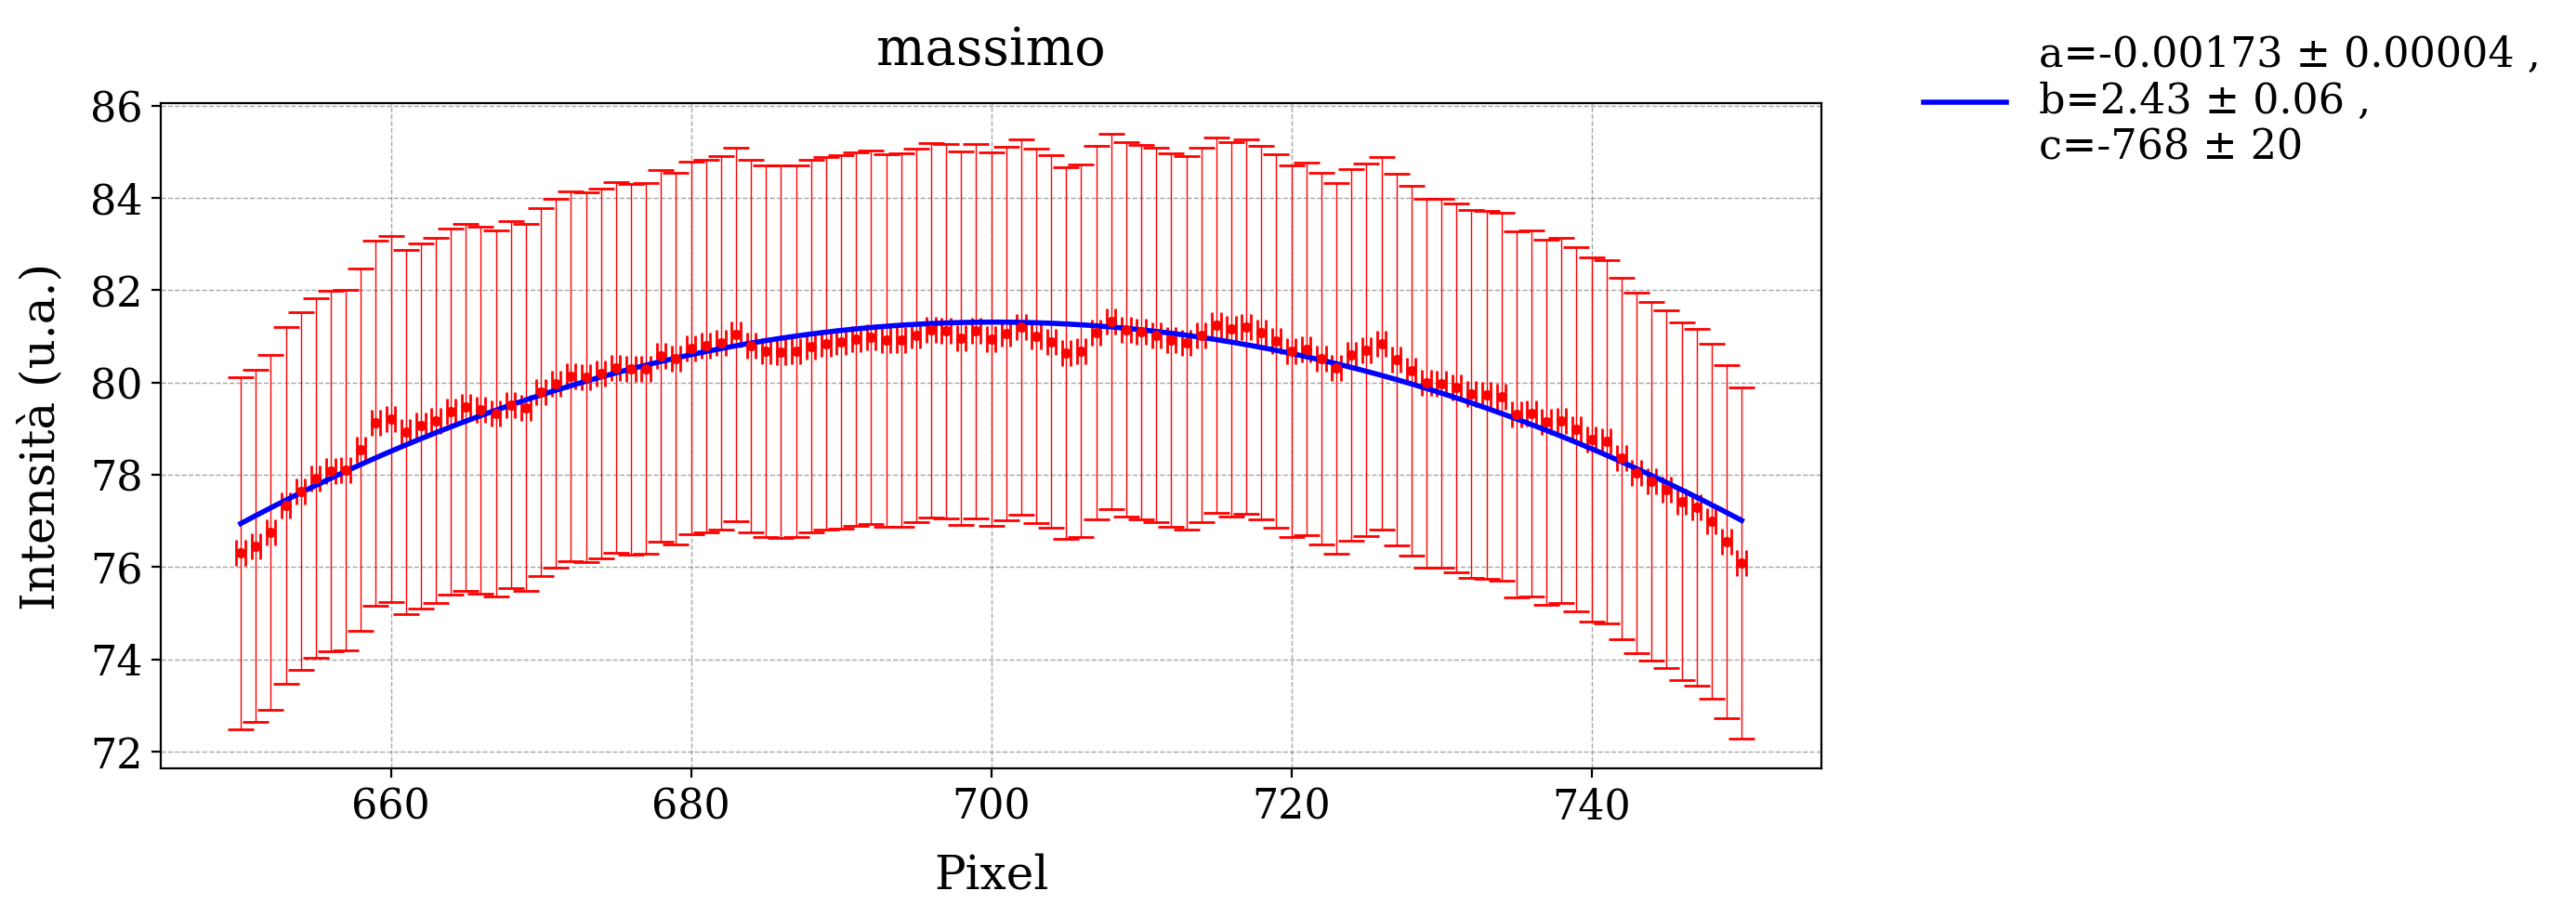

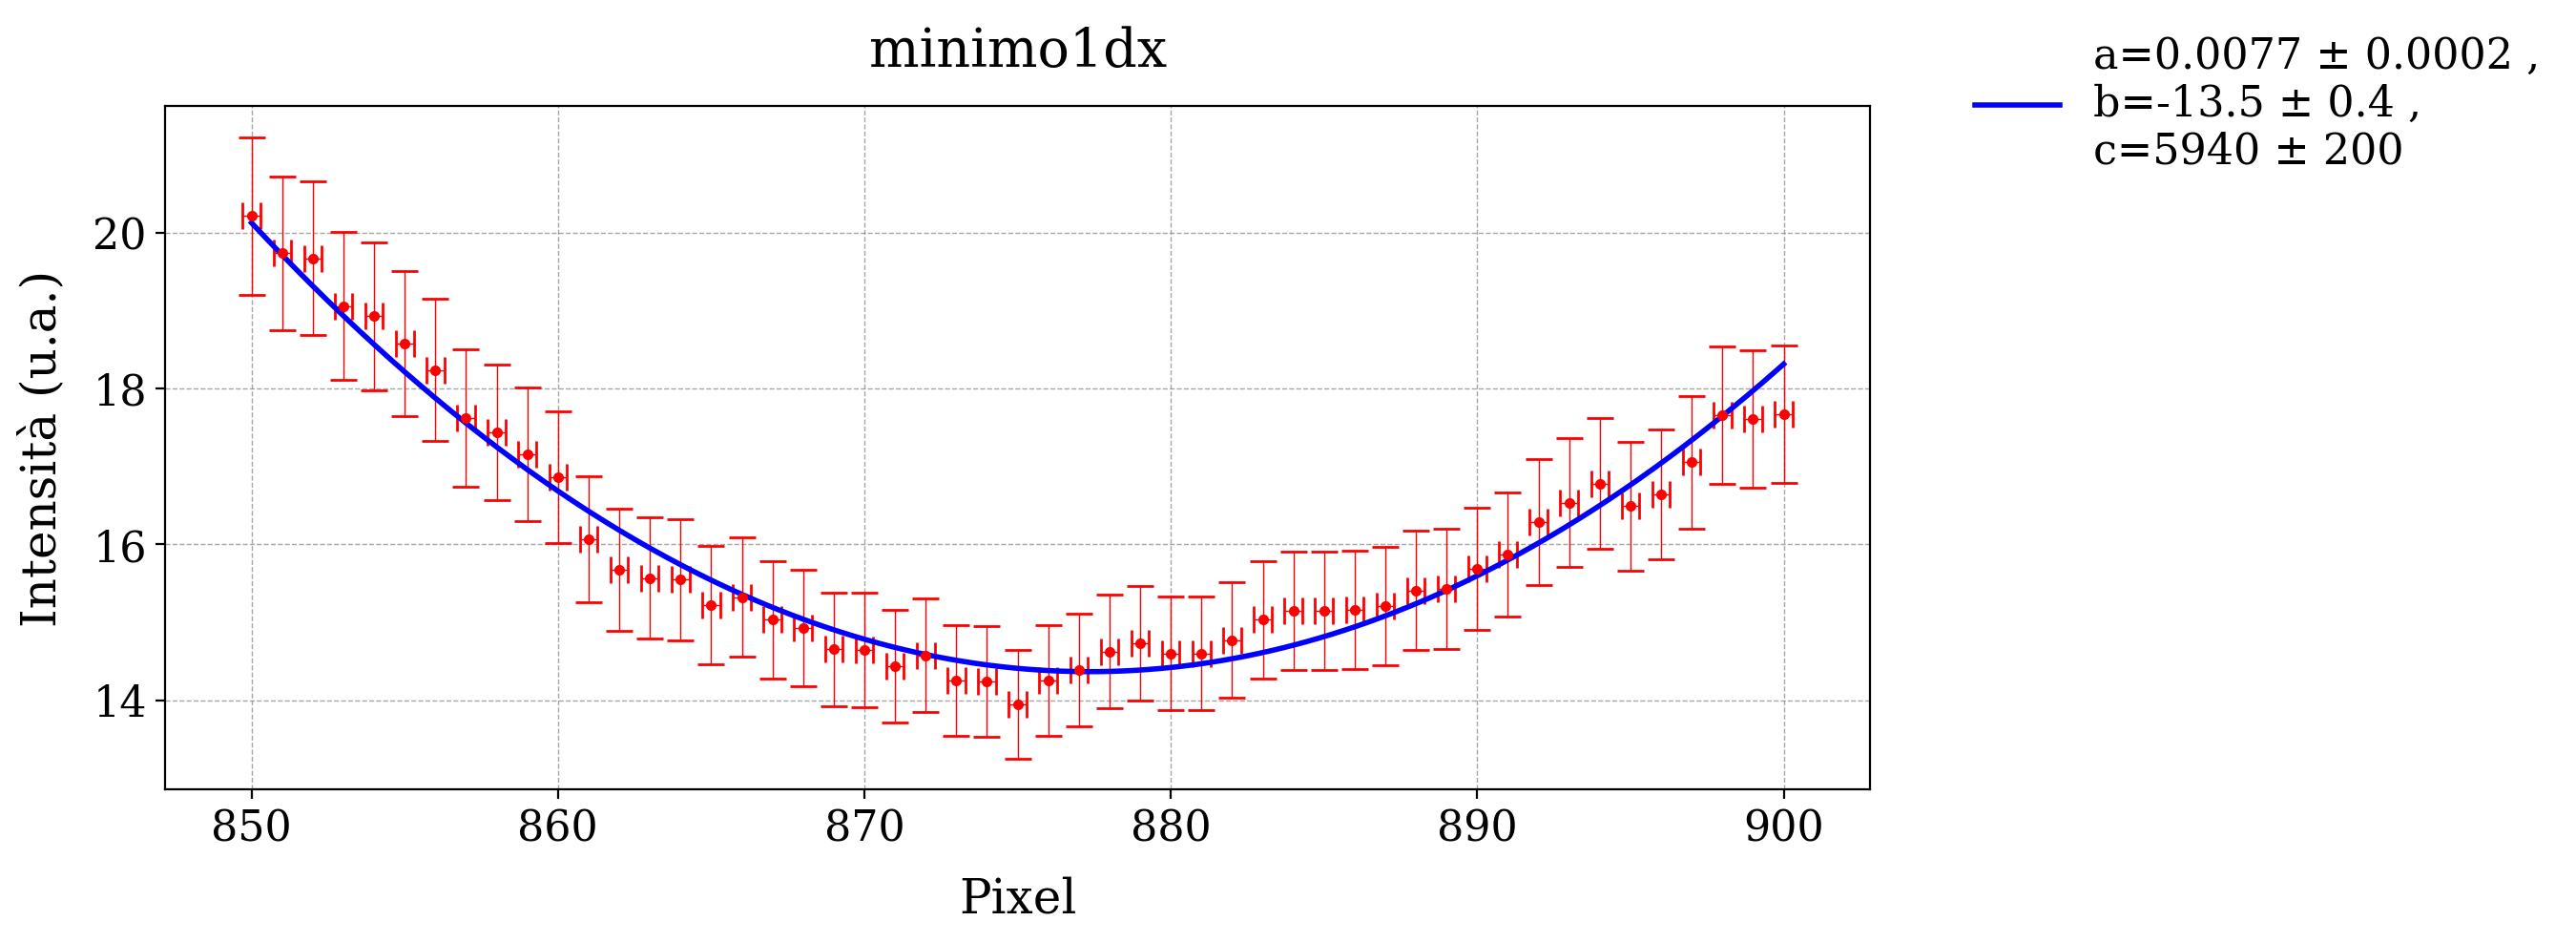

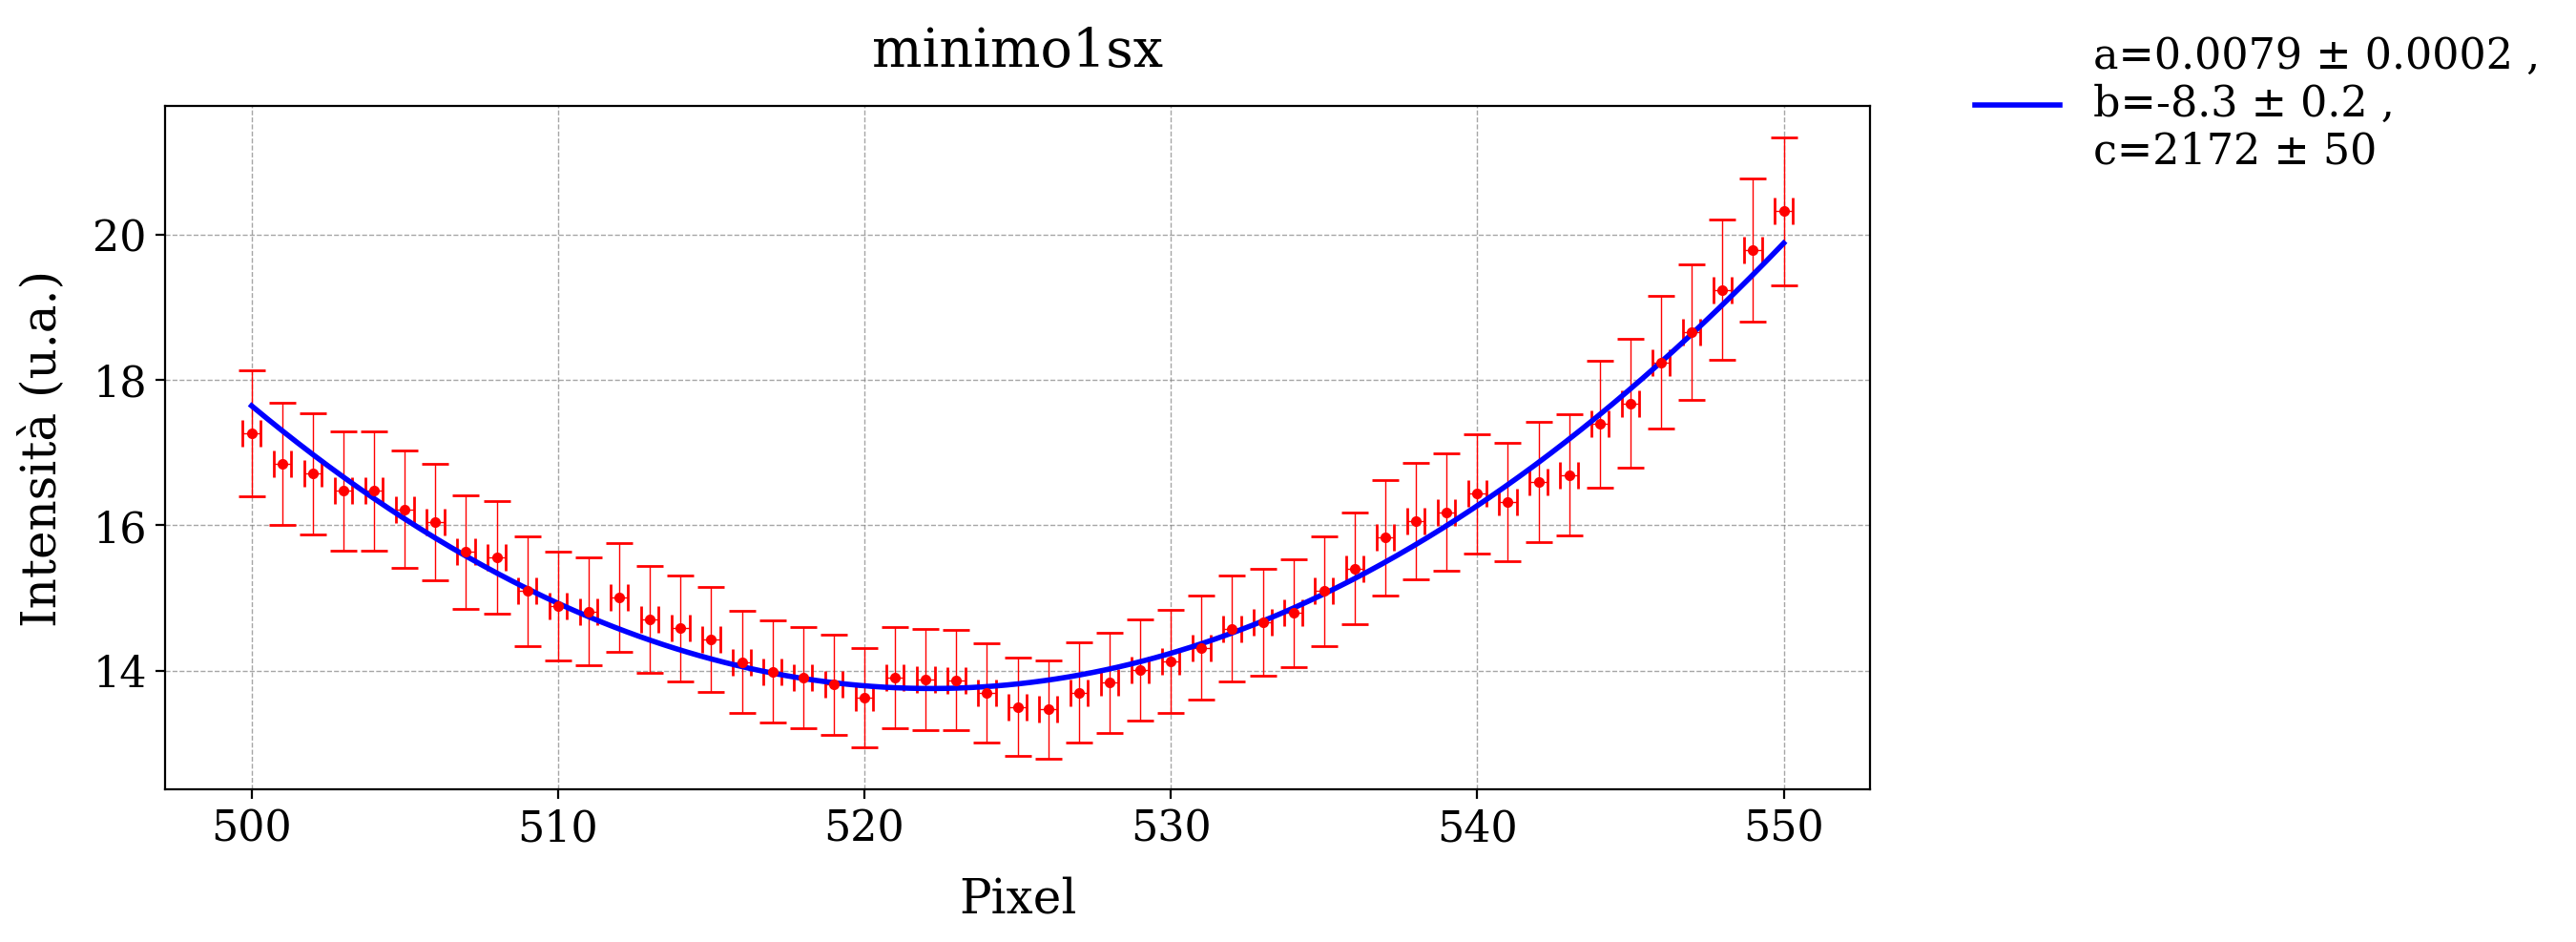

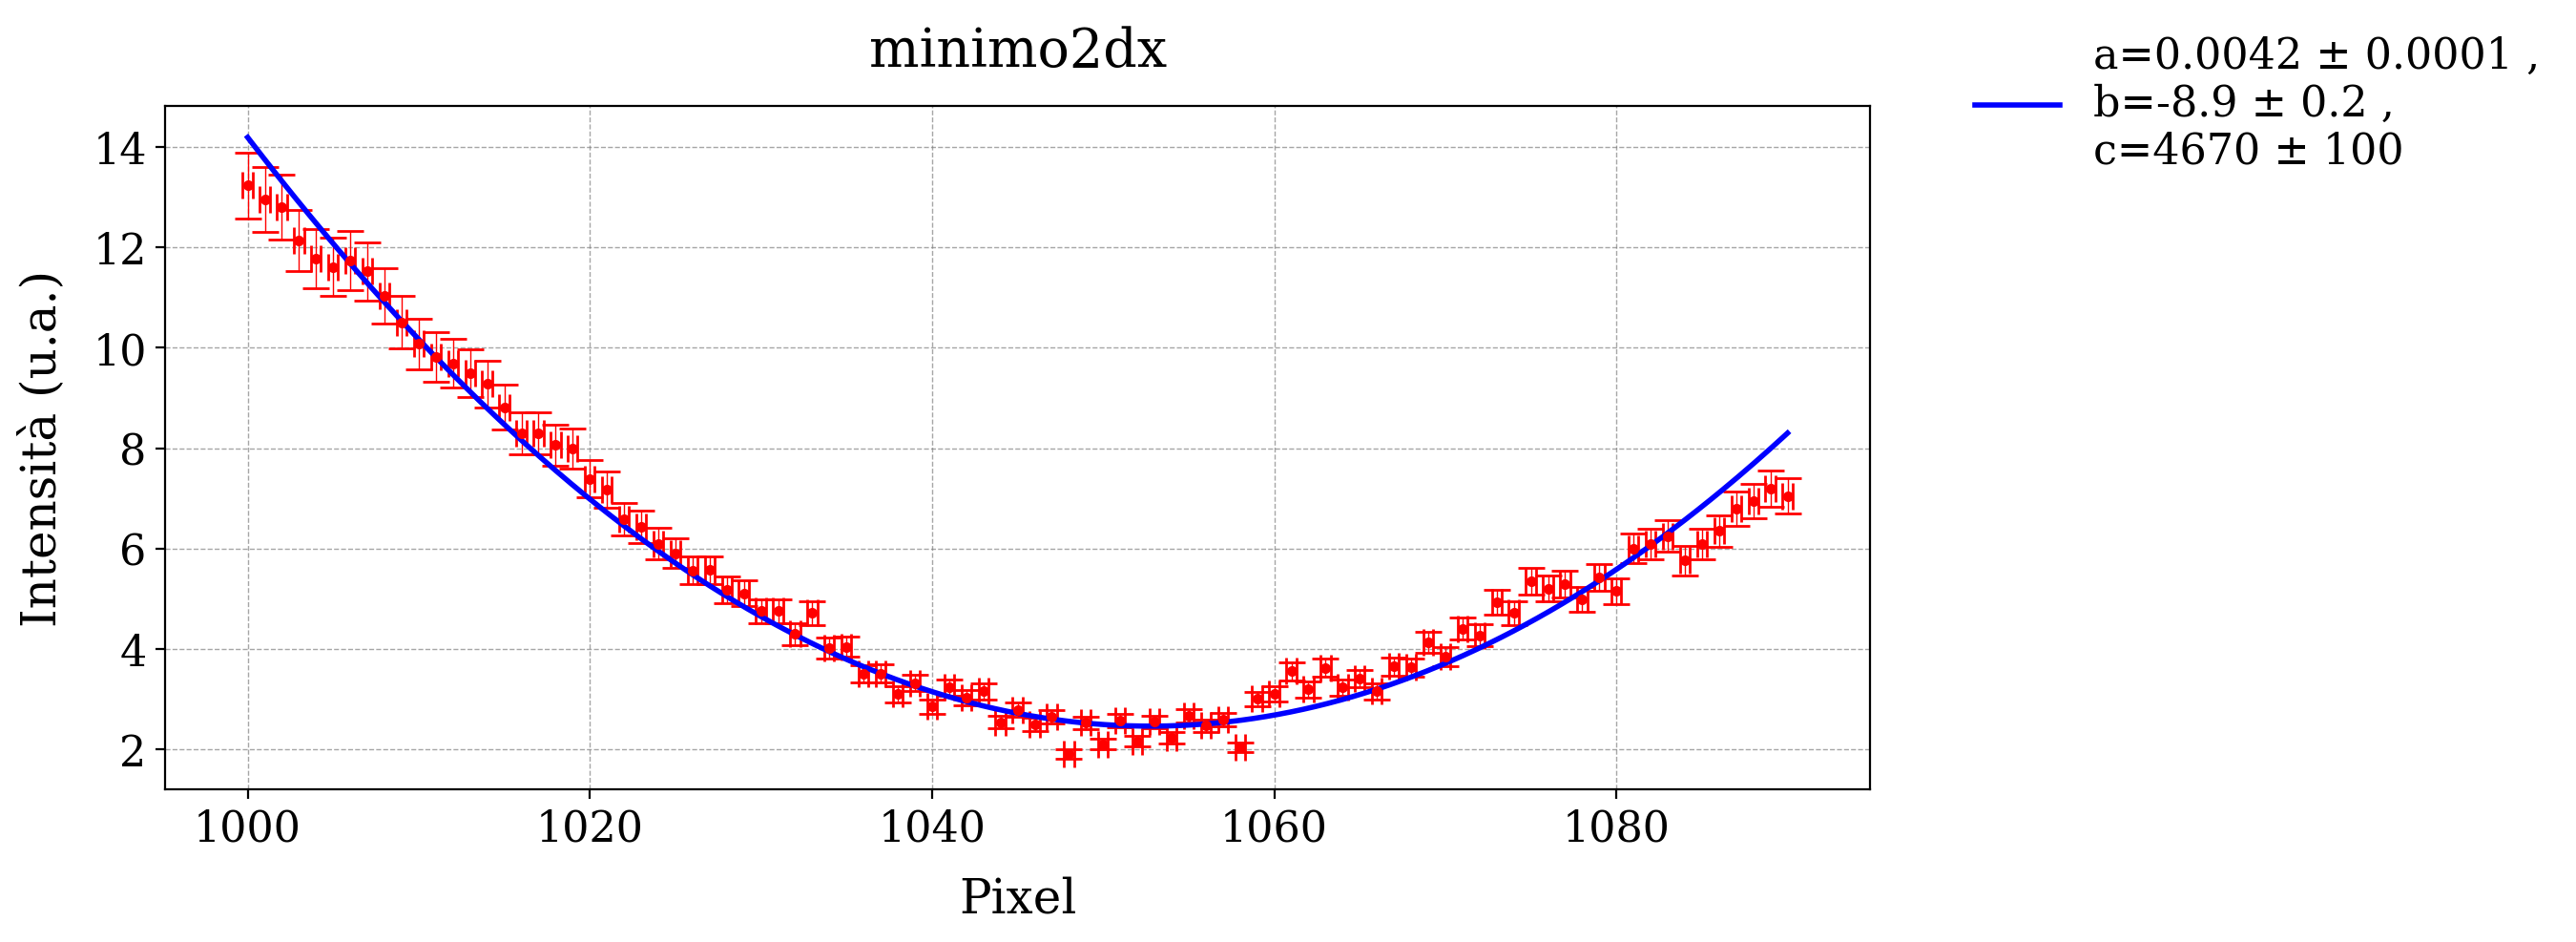

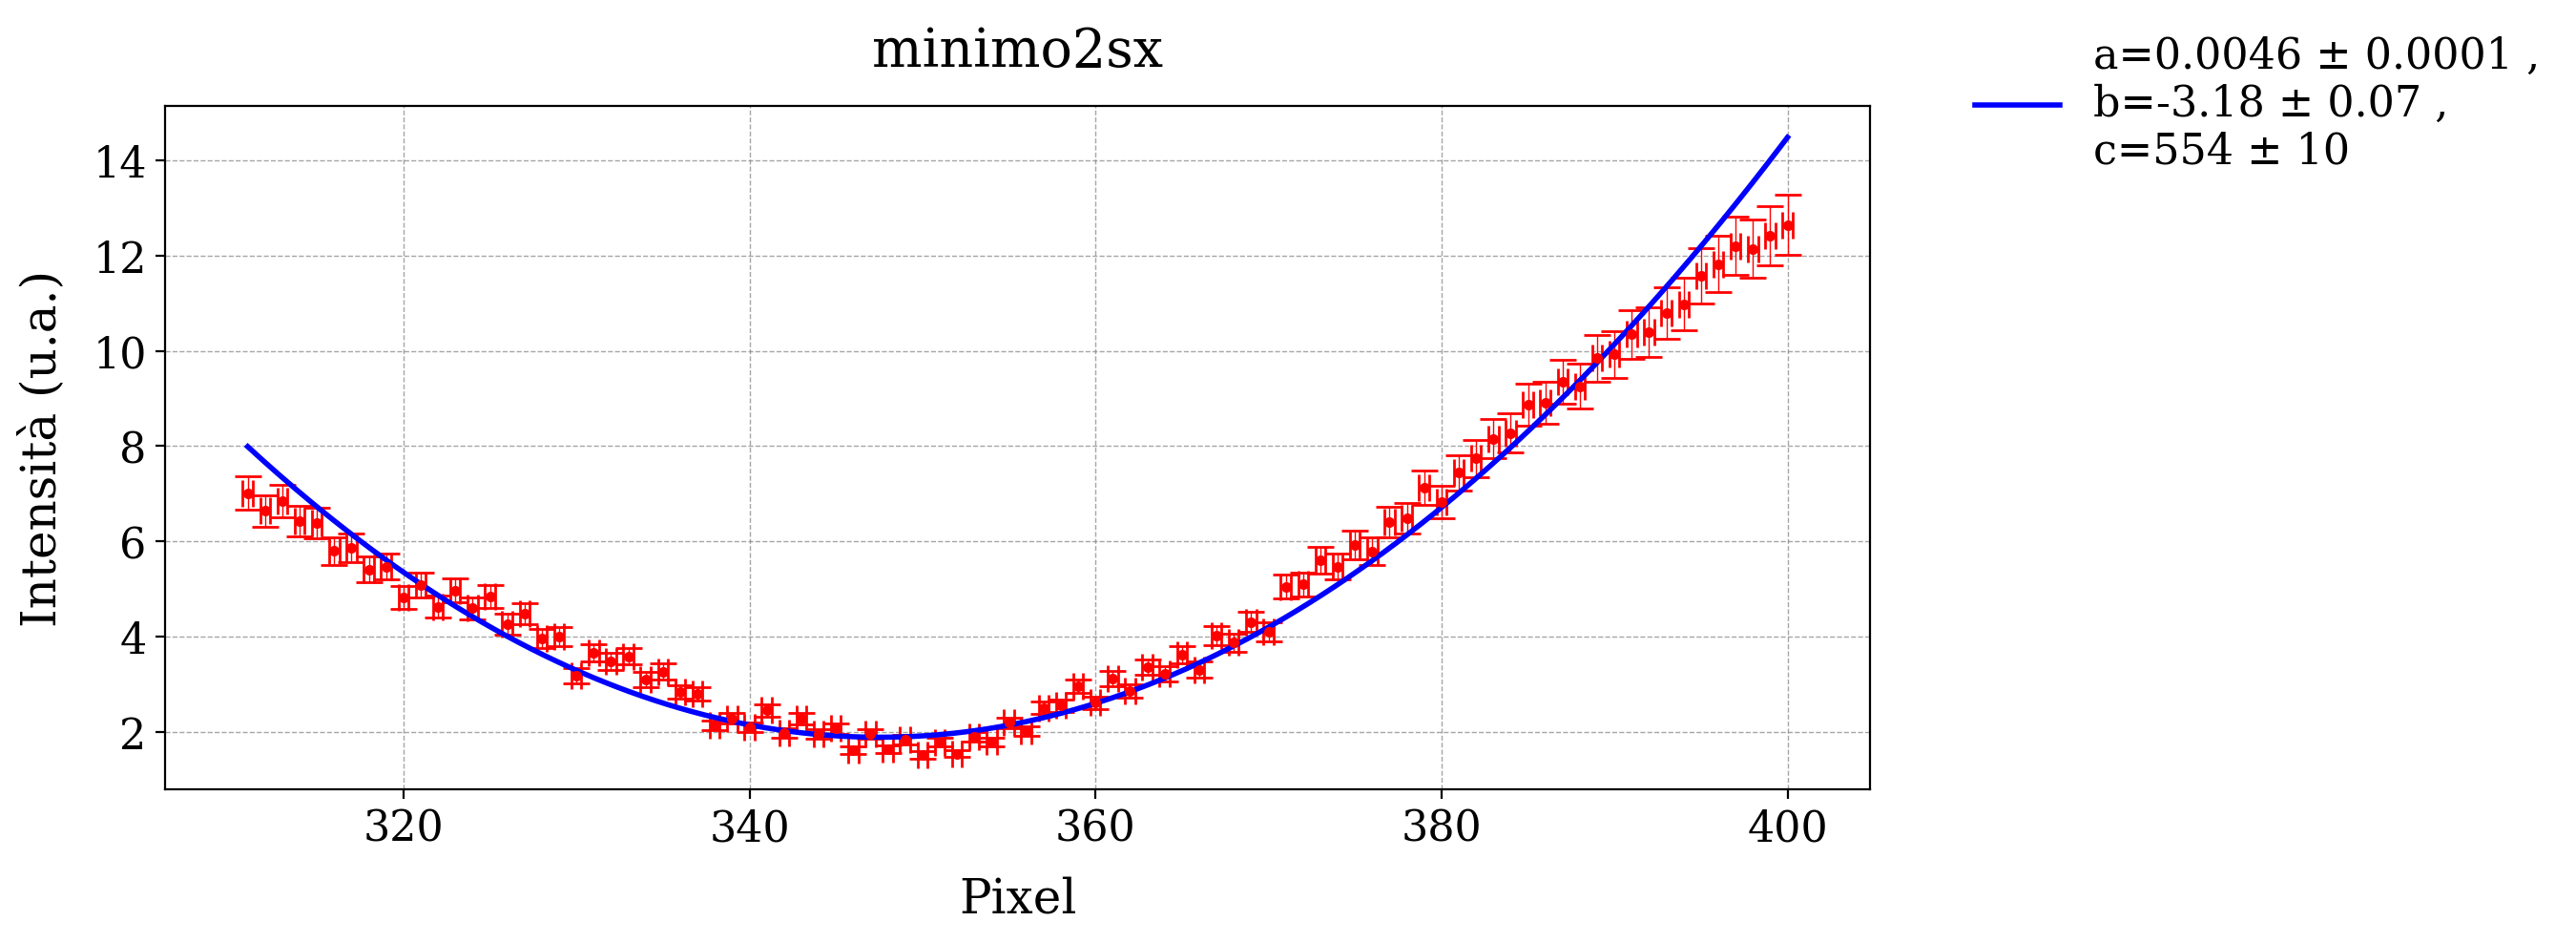

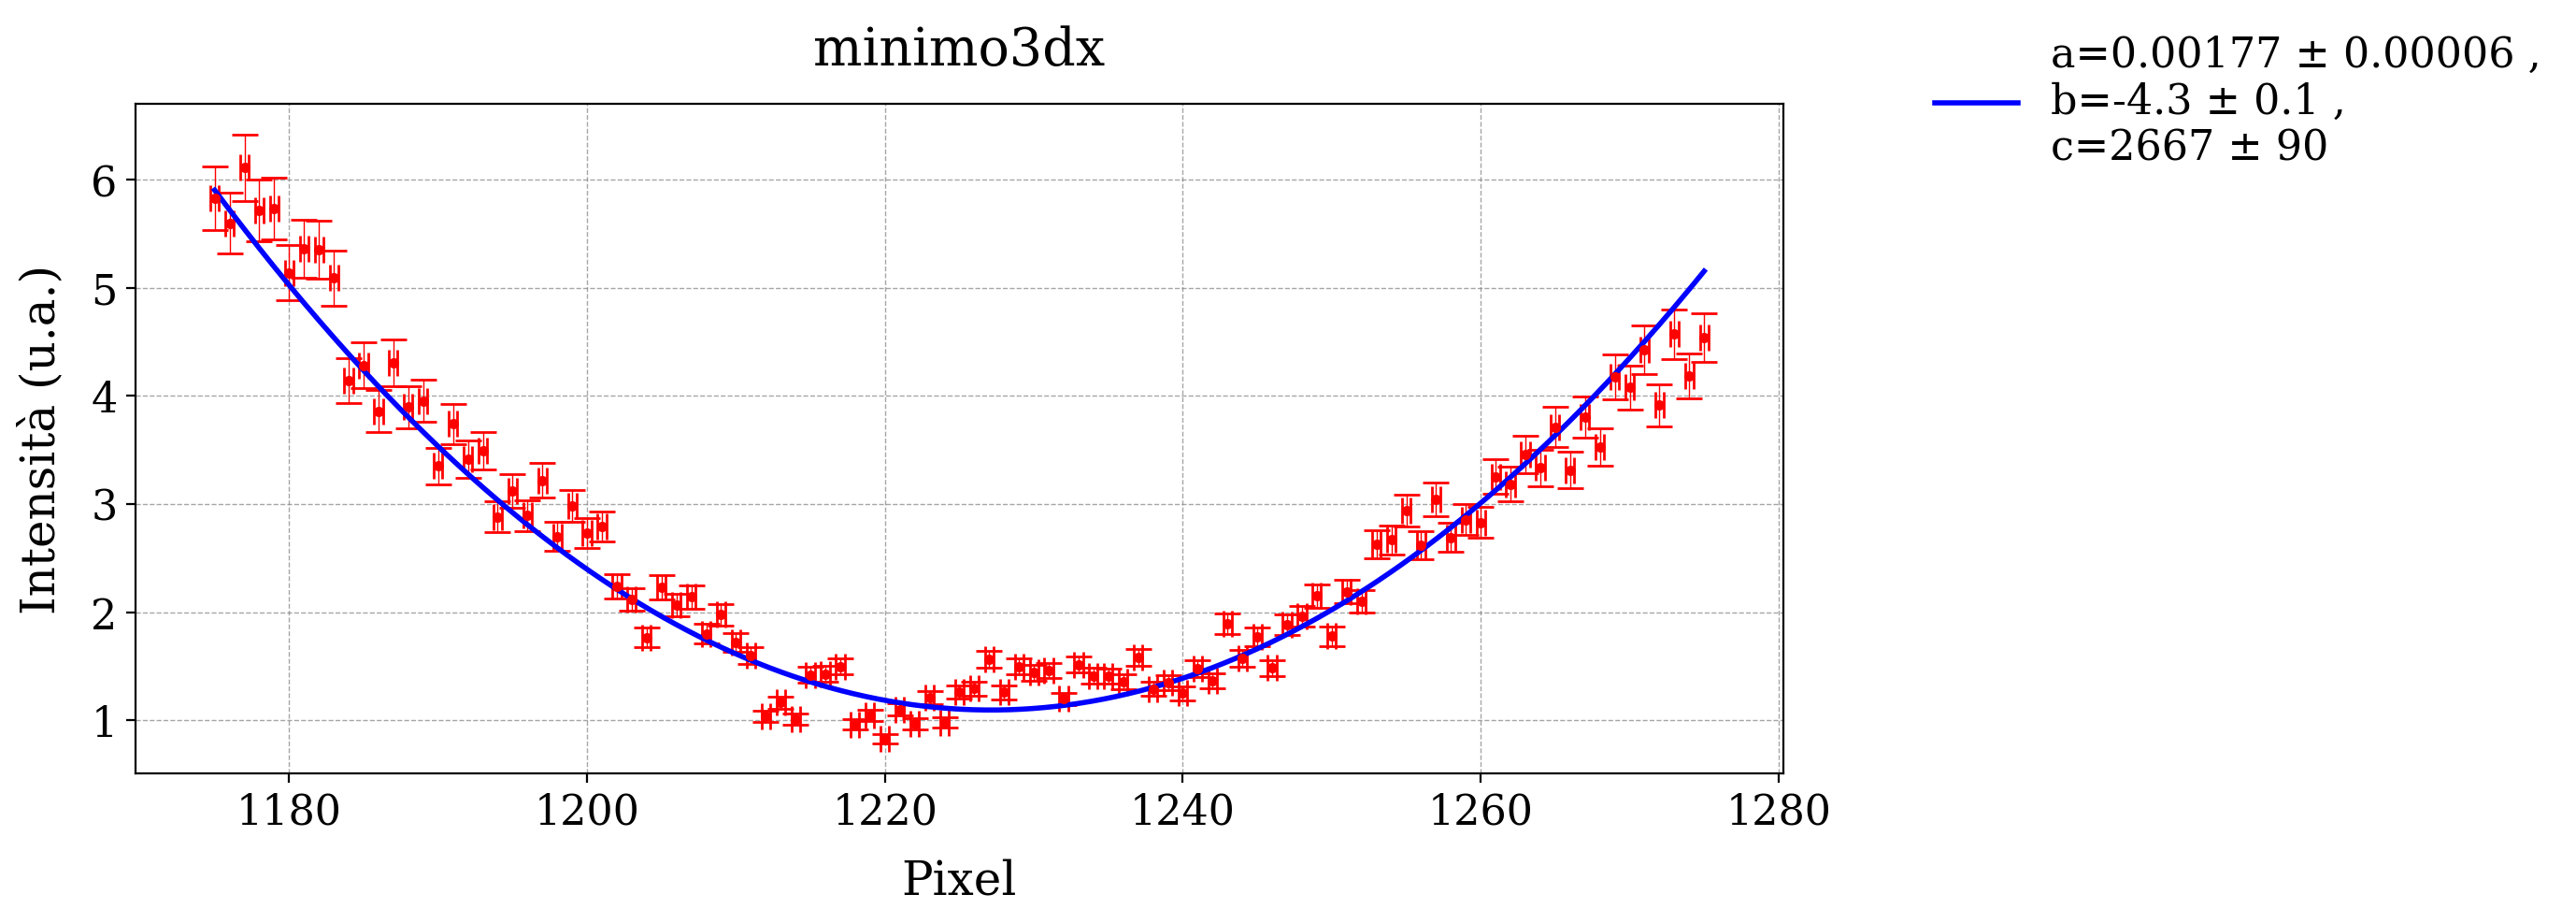

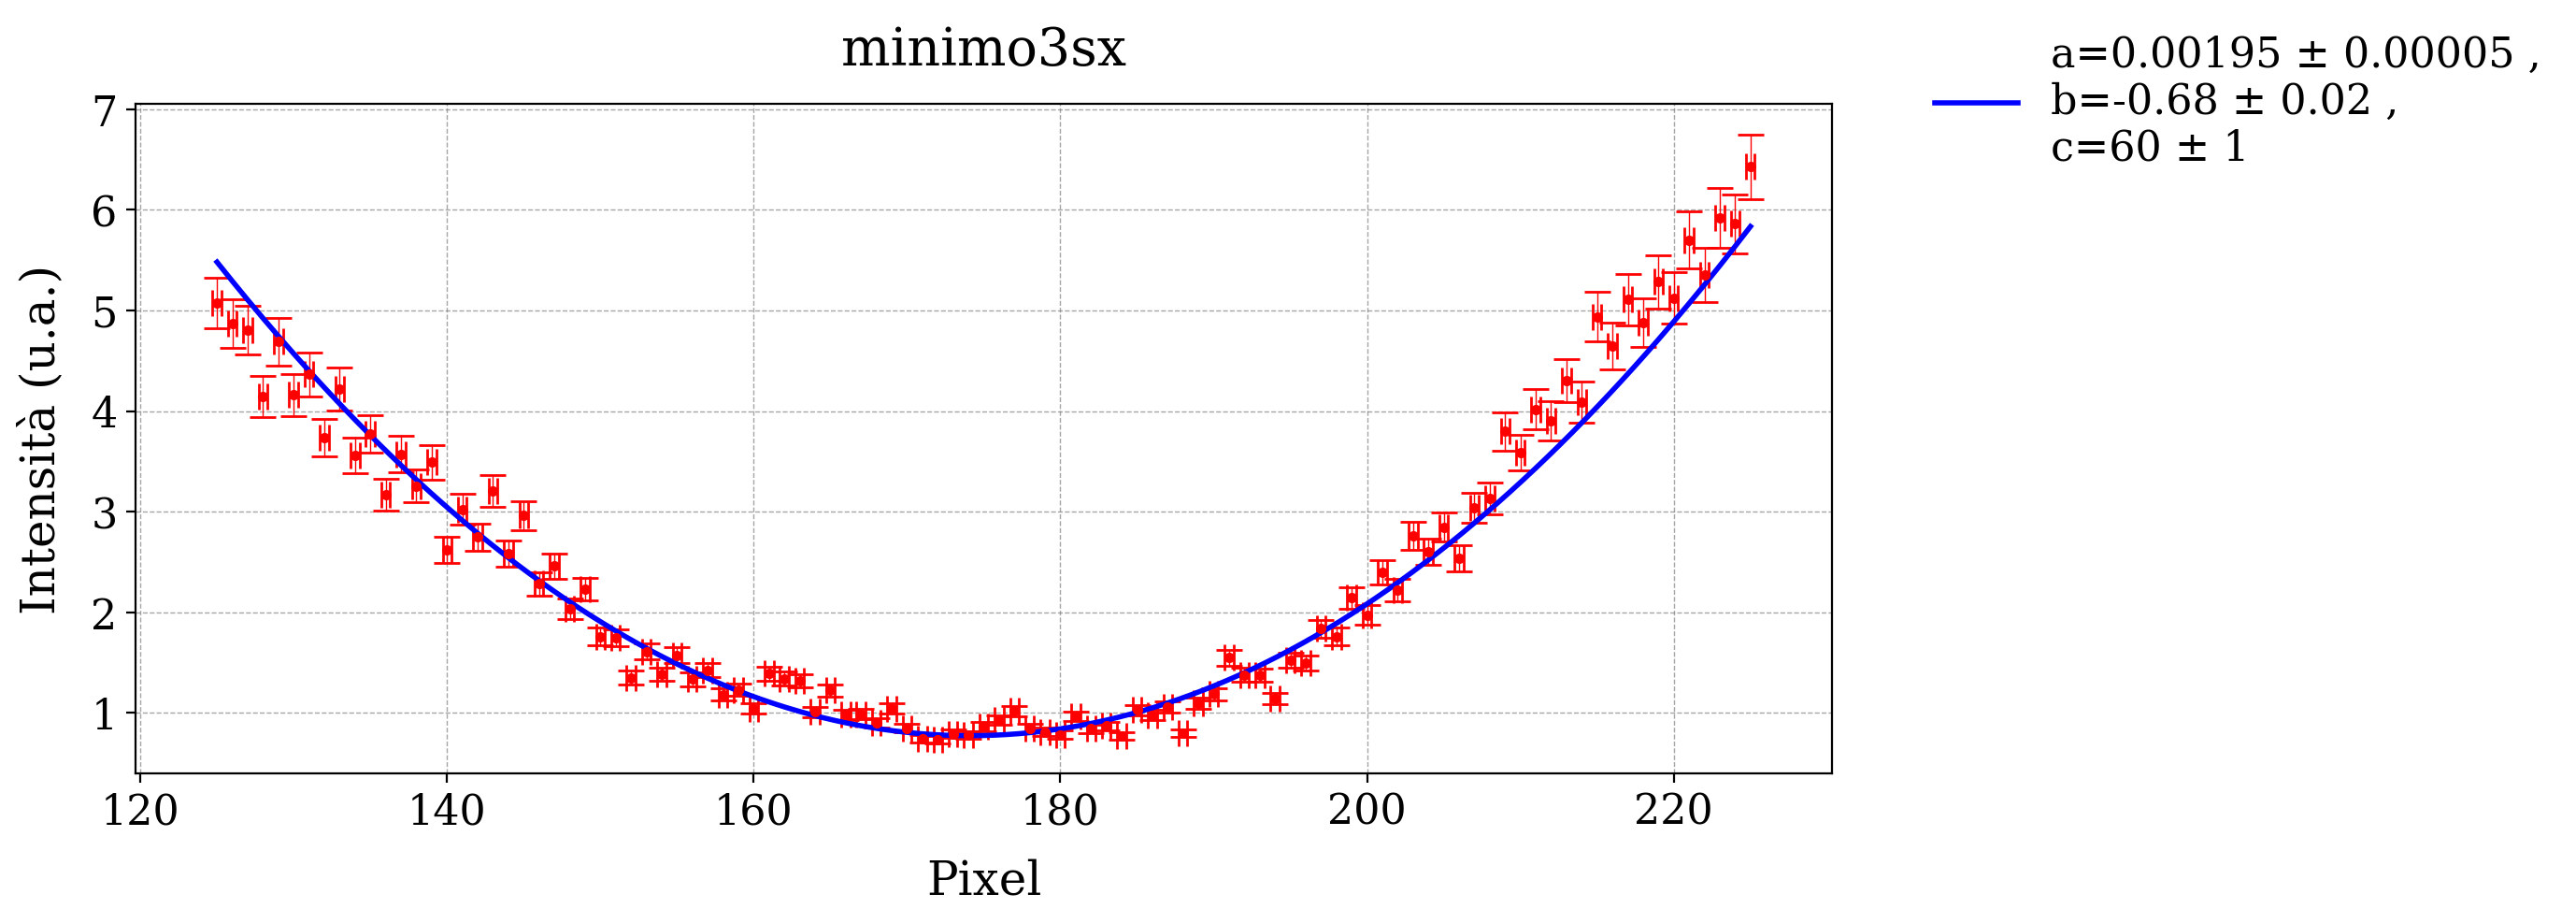

In [5]:
parametri = {}
file_output = "analizzati.txt"
file_chi = "chi_quadratici.txt"
f.inizializza_output(file_output)
f.inizializza_output(file_chi)
def parabola(B, x):
        (a, b, c) = B
        return a*x**2 + b*x + c
for (titolo,dati) in data.items():
    fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
    xdata = [dati["pixel"],
            np.full_like(dati["pixel"],1/np.sqrt(12))]
    ydata = [dati["intensita"],
            np.sqrt( err*2 + (0.05*dati["intensita"])**2 )]
    gf.parametri_grafico(ax,titolo,xlabel="Pixel",ylabel="Intensità (u.a.)")
    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

    x = xdata[0]
    y = ydata[0]
    a0 = - (np.max(y) - np.min(y)) / (np.max(x) - np.min(x))**2
    beta0 = [a0,
            -2 * a0 * np.mean(x),
            np.mean(y)]
    anal = f.fit(xdata,ydata,parabola,beta0, chi=False)
    f.chi_quadro(xdata[0],ydata[0],ydata[1],[anal[0][0],anal[1][0],anal[2][0]],parabola,file_chi,titolo)
    a = anal[0][0]
    sa = anal[0][1]
    b = anal[1][0]
    sb = anal[1][1]
    c = anal[2][0]
    sc = anal[2][1]
    x = [-b/(2*a),
         f.propaga_incertezza("-b/(2*a)",
                              ["a","b"],
                              [a,b],
                              [sa,sb],
                              ritorno=True)[0]]
    y = [-(b**2 - 4*a*c)/(4*a),
         f.propaga_incertezza("-(b**2 - 4*a*c)/(4*a)",
                              ["a","b","c"],
                              [a,b,c],
                              [sa,sb,sc],
                              ritorno=True)[0]]

    with open(file_output,'a') as out:
        out.write(f"Fit {titolo}\n")
        out.write(f"\tx del vertice = {gf.formatta_errore(x[0],x[1],txt=True)}\n")
        out.write(f"\ty del vertice = {gf.formatta_errore(y[0],y[1],txt=True)}\n")
        out.write(f"\ta = {gf.formatta_errore(a,sa,txt=True)}\n")
        out.write(f"\tb = {gf.formatta_errore(b,sb,txt=True)}\n")
        out.write(f"\tc = {gf.formatta_errore(c,sc,txt=True)}\n\n")

    label = (
        f"a={gf.formatta_errore(a,sa,txt=True)},\n"
        f"b={gf.formatta_errore(b,sb,txt=True)},\n"
        f"c={gf.formatta_errore(c,sc,txt=True)}"
    )

    parametri[titolo] = [[a,sa],[b,sb],[c,sc]]
    x = np.linspace(np.min(xdata[0]), np.max(xdata[0]), 500)
    y = parabola([anal[0][0], anal[1][0], anal[2][0]], x)
    ax.plot(x, y, color="blue",label = label)

    gf.salva_grafico(fig,f"{titolo}.pdf")

    del xdata,ydata,x,y,a,b,c

In [6]:
letti = pd.read_csv("Results_fend.csv")
fend = { "pixel" : letti["pixel"],
        "intensita" : letti["grigio"]}

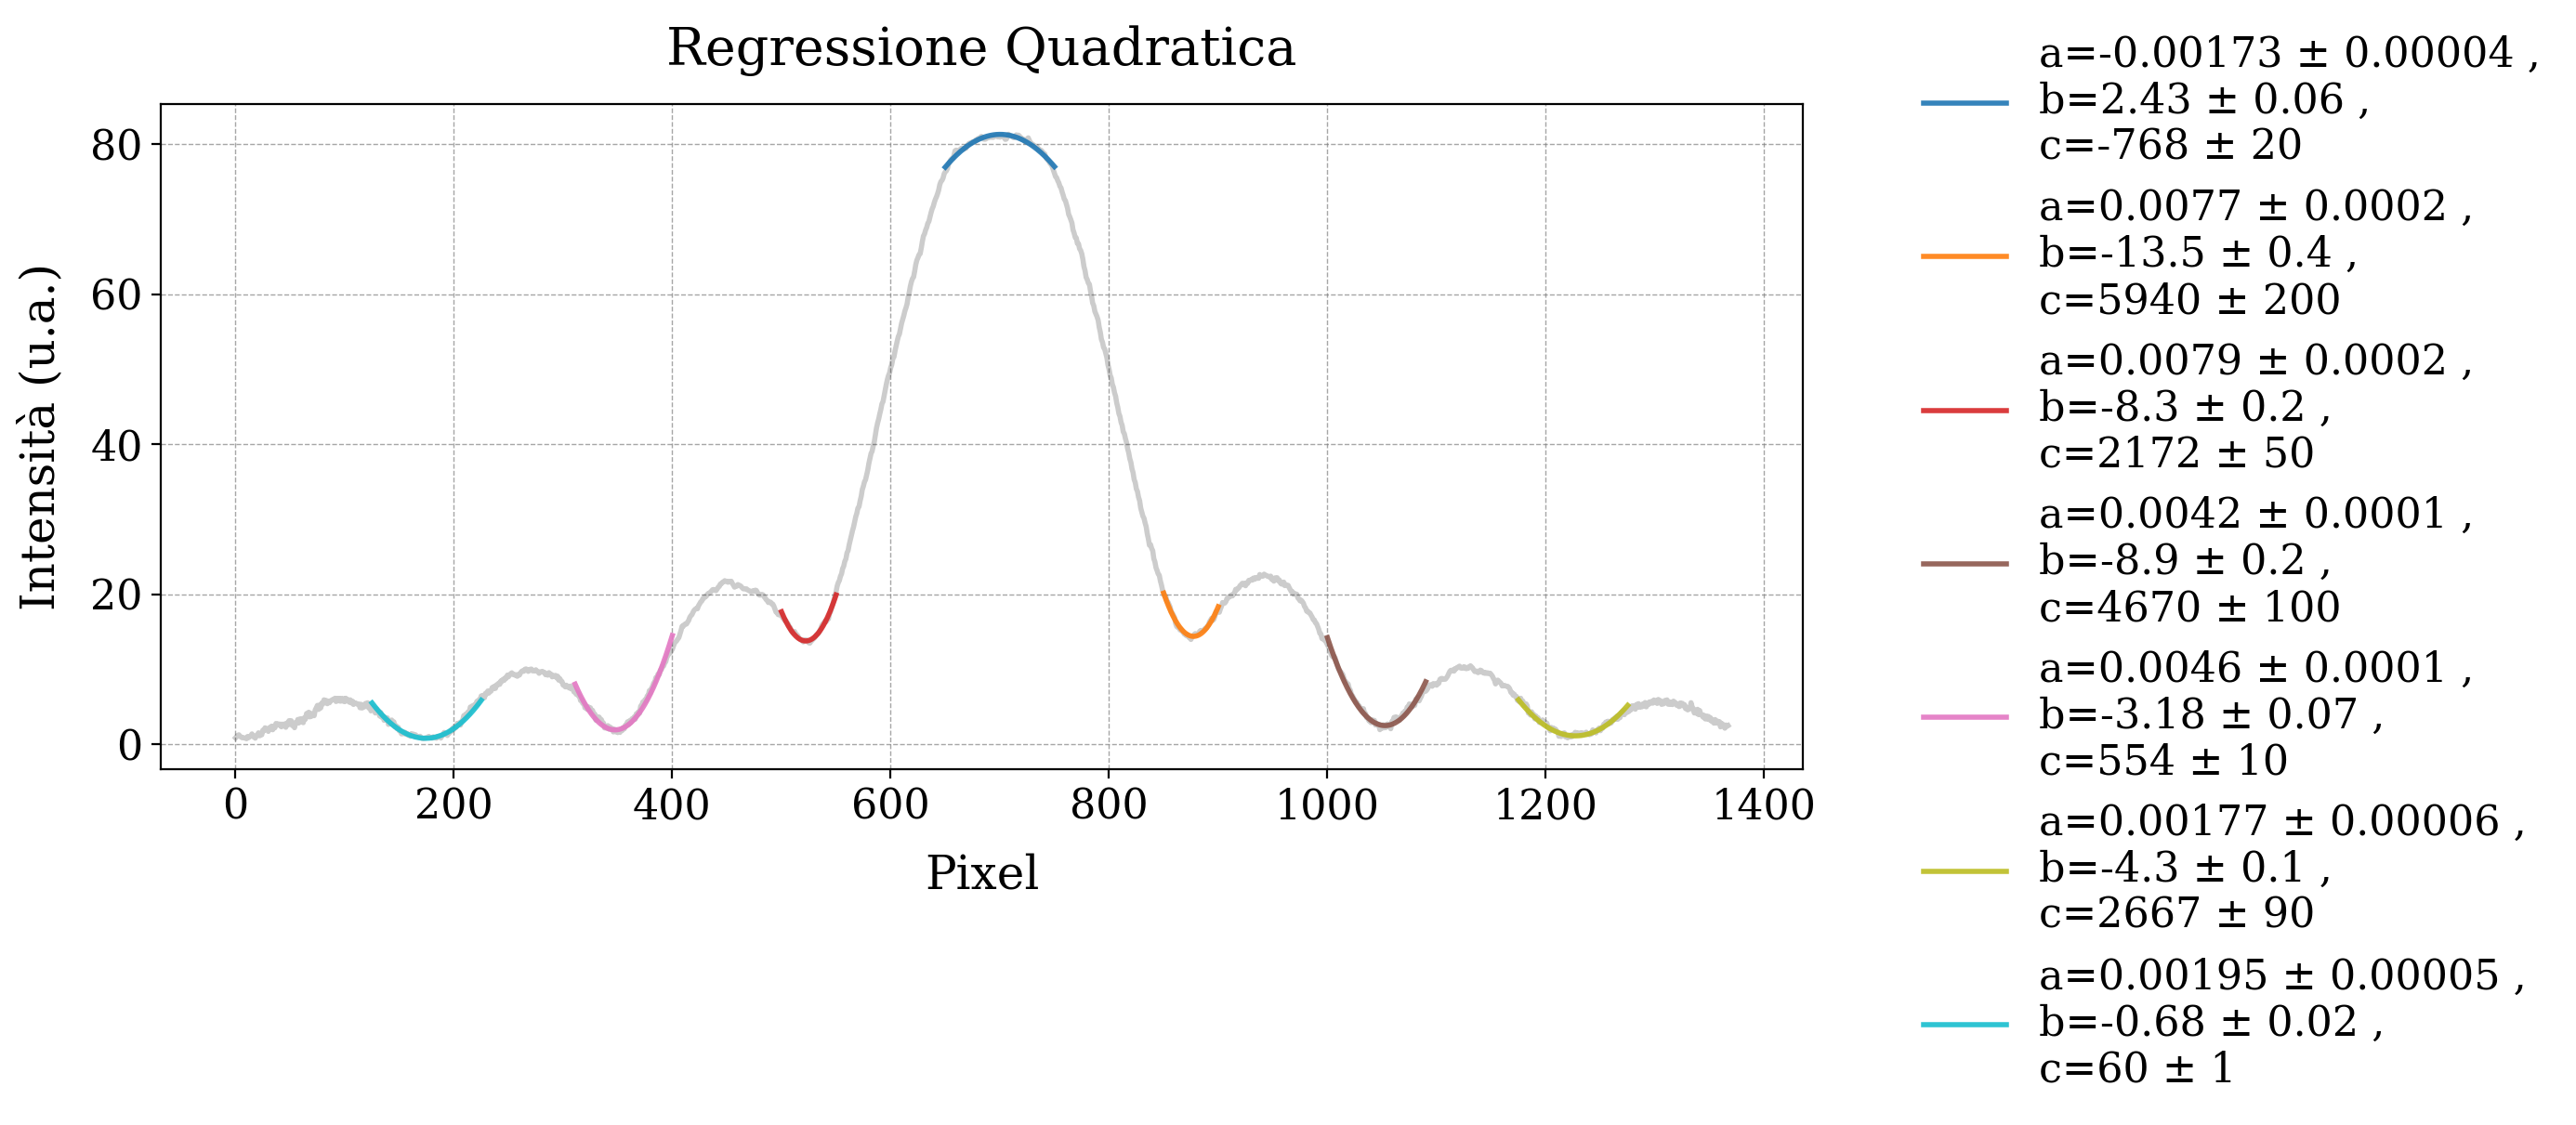

In [7]:
x_data = fend["pixel"]
y_data = fend["intensita"]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
gf.parametri_grafico(ax, "Regressione Quadratica", xlabel="Pixel", ylabel="Intensità (u.a.)")

ax.plot(x_data, y_data, color="black", alpha=0.2)

# colormap discreta con tanti colori quanti sono i fit
cmap = plt.cm.tab10
colori = cmap(np.linspace(0, 1, len(data)))

for (titolo, dati), colore in zip(data.items(), colori):
    [[a,sa],[b,sb],[c,sc]] = parametri[titolo]

    x = np.linspace(np.min(dati["pixel"]), np.max(dati["pixel"]), 500)
    y = parabola([a,b,c], x)

    label = (
        f"a={gf.formatta_errore(a,sa,txt=True)},\n"
        f"b={gf.formatta_errore(b,sb,txt=True)},\n"
        f"c={gf.formatta_errore(c,sc,txt=True)}"
    )

    ax.plot(
        x, y,
        color=colore,
        linestyle="-",
        linewidth=2,
        alpha=0.9,
        label=label
    )

gf.salva_grafico(fig,"regressione_quadratica.pdf")

# 3. Fit Lineare

In [8]:
x = np.array([635,1270,1905])
sx = np.array([7,7,7])
y = np.array([0.0010,0.0019,0.0029])
#y = np.array([0.0029,0.0019,0.0010])
sy = [np.array([0.0002,0.0001,0.0001]),
      np.array([0.0002,0.0002,0.0003])]
val = {" Sinistra" : [[x,sx],[y,sy[0]]],
       "Destra" : [[x,sx],[y,sy[1]]]}
del x,y,sx,sy

In [9]:
file_output = "chi_fit_lineare.txt"
f.inizializza_output(file_output)
def lineare(par,x):
    return par[0] + par[1] * x
par = {}

for titolo,valori in val.items():
    [[x,sx],[y,sy]] = valori
    anal = f.minimi_quadrati(x,y,sy)
    print(f"Ala {titolo}")
    print(f"\ta = {gf.formatta_errore(anal[0][0],anal[0][1],txt=True)}")
    print(f"\tb = {gf.formatta_errore(anal[1][0],anal[1][1],txt=True)}\n")
    f.chi_quadro(x,y,sy,[anal[0][0],anal[1][0]],lineare,file_output,f"Ala {titolo}",n=12,f=4)
    par[titolo] = anal

Ala  Sinistra
	a = -0.0000 ± 0.0002 
	b = 0.0000015 ± 0.0000002 

Ala Destra
	a = 0.0000 ± 0.0003 
	b = 0.0000015 ± 0.0000003 



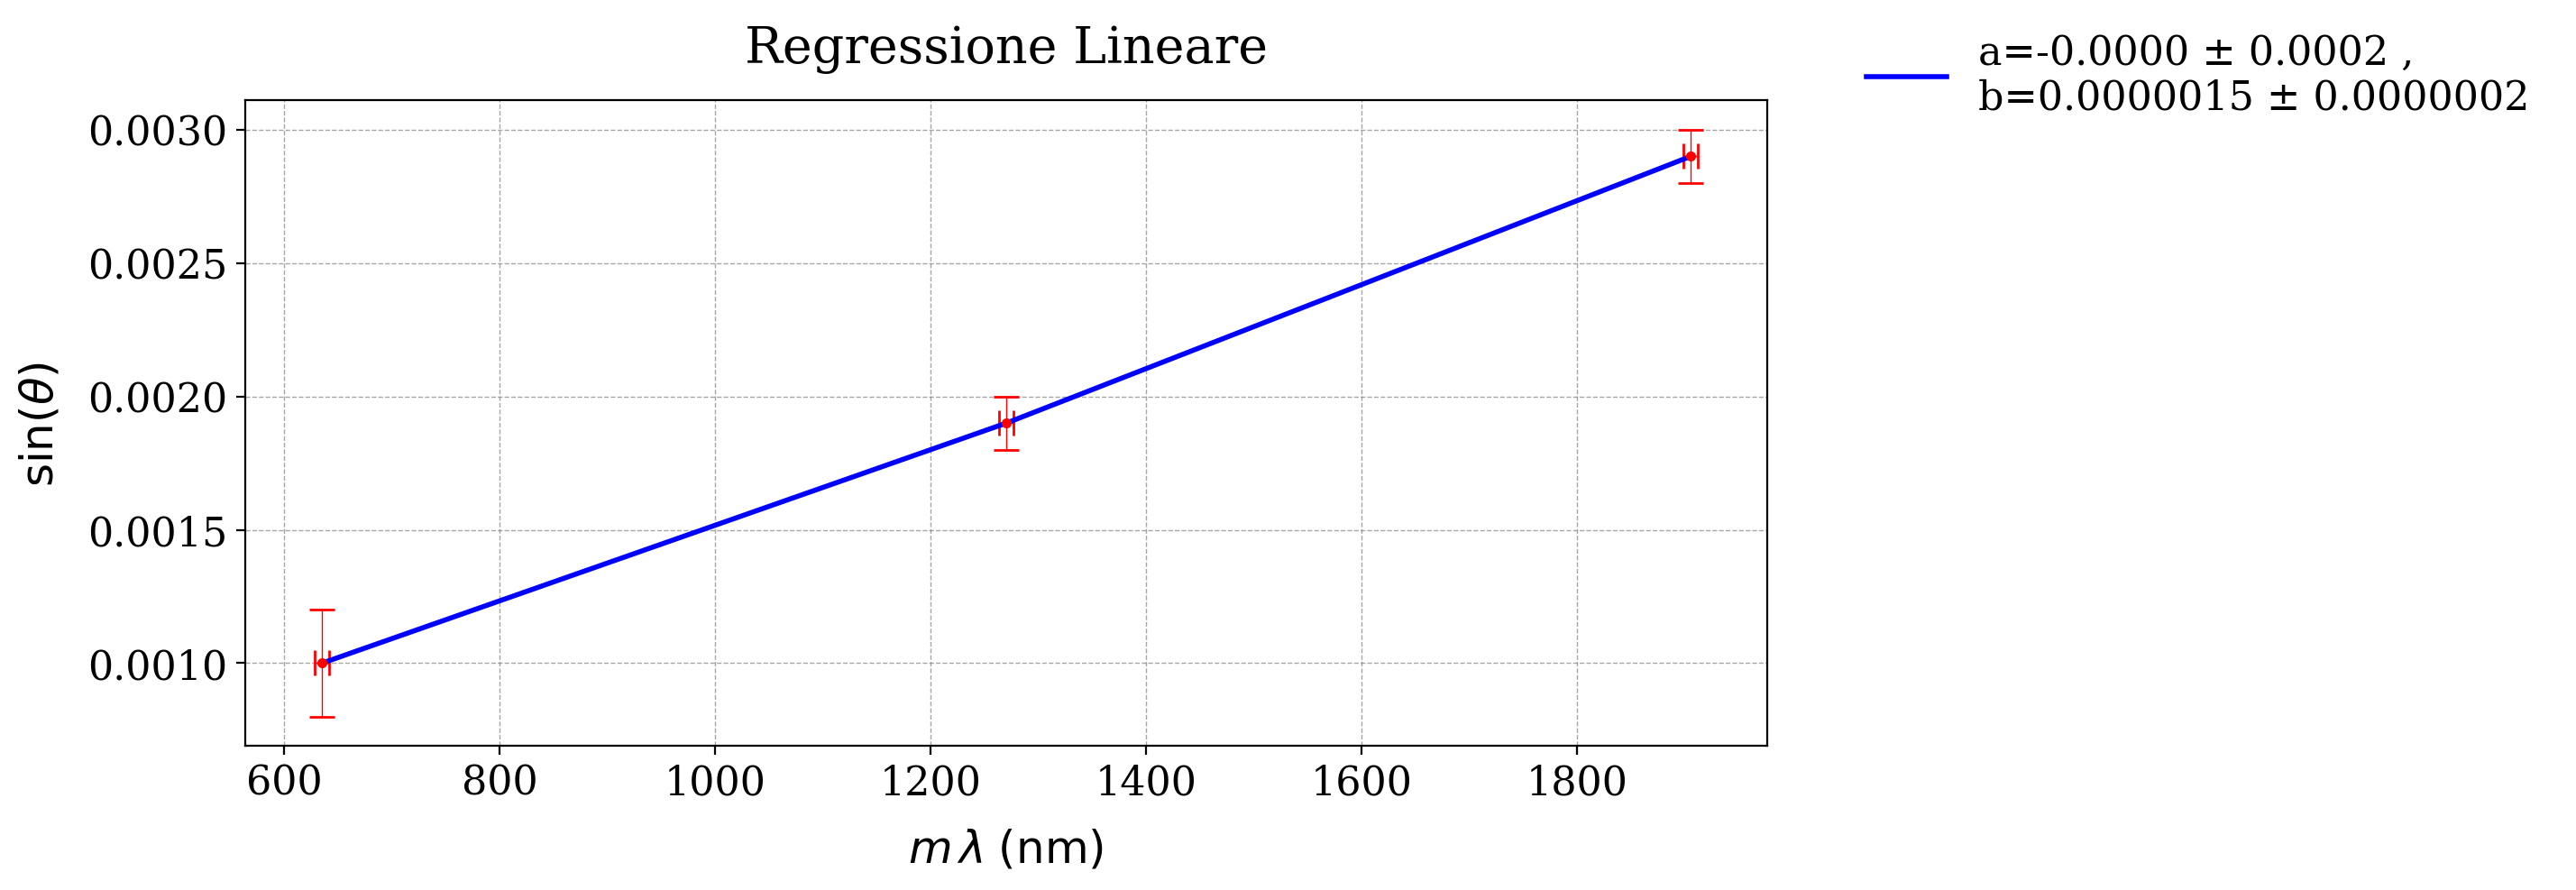

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
gf.parametri_grafico(ax, "Regressione Lineare", xlabel=r"$m\,\lambda\;(\mathrm{nm})$", ylabel=r"$\sin(\theta)$")

for i,(valori,parametri) in enumerate(zip(val.values(),par.values())):
    if i == 1: break
    [[x,sx],[y,sy]] = valori
    [[a,sa],[b,sb],cov] = parametri

    ax.errorbar(x, y, xerr=sx, yerr=sy, color="red", fmt=".", **gf.default_error_params())

    x_val = np.linspace(np.min(x), np.max(x), 500)
    y_val = lineare([a,b],x_val)

    label = (
        f"a={gf.formatta_errore(a,sa,txt=True)},\n"
        f"b={gf.formatta_errore(b,sb,txt=True)}"
    )

    ax.plot(x, y, color="blue", label=label)

gf.salva_grafico(fig,"regressione_lineare.pdf")